---
title: "intractable bayesian inference"
execute:
  # echo: false
  freeze: auto  # re-render only when source changes
format:
  html:
    code-fold: true
    code-summary: "Show the code"
---

In the previous section, we solved a simple 2x2 grid where the mouse only had to worry about whether a fox was present or absent. While that was a great starting point, the real world is rarely that discrete. To move toward a more realistic model, we must consider the world as a continuous space.

## moving to continuous states

Imagine that the mouse is no longer just asking "is there a fox?" but is instead trying to estimate the **distance** of the fox from the burrow.

* **External state $x^\star$:** The physical, objective distance of the fox (e.g., 100 meters).
* **Hidden state $x$:** The mouse’s internal representation of that distance.
* **Sensory outcome $y$:** The continuous intensity of the fox’s scent reaching the mouse’s nose.

In this scenario, the mouse’s **generative model** is no longer a simple table. It is a continuous **joint probability density function (PDF)**, $p(x, y)$. This function maps how likely a specific smell intensity $y$ is, given a specific distance $x$, weighted by how likely the mouse thinks that distance was in the first place (the prior).


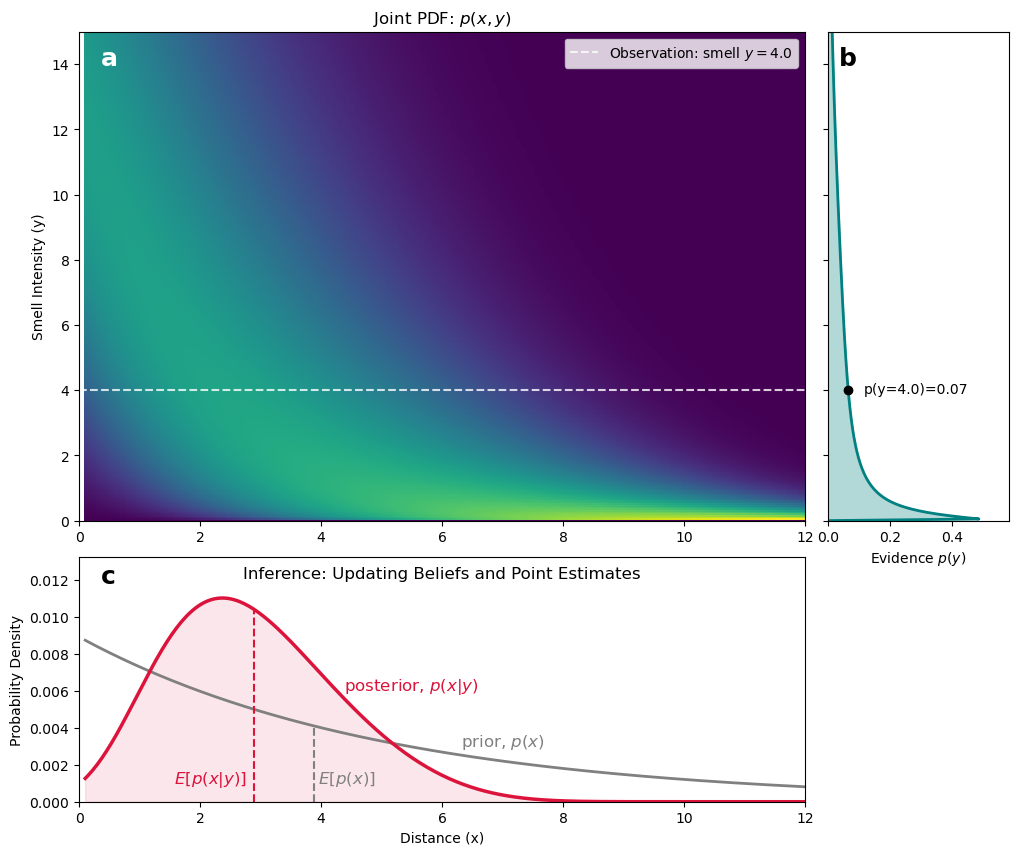

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma
from matplotlib.colors import PowerNorm

# 1. Setup the axes
x = np.linspace(0.1, 12, 300) 
y = np.linspace(0, 15, 300)   
X, Y = np.meshgrid(x, y)

# 2. Define the Generative Model
prior_pdf = np.exp(-0.2 * x) 
prior_pdf /= prior_pdf.sum()  

k = 1 + 5 * np.exp(-0.5 * x) 
mean_y = 15 * np.exp(-0.4 * x)
theta = mean_y / k
likelihood_pdf = gamma.pdf(Y, a=k, scale=theta)

# 3. Compute Joint PDF
joint_pdf = likelihood_pdf * prior_pdf

# 4. Marginal Likelihood (Evidence)
evidence_y = np.sum(joint_pdf, axis=1)

# 5. Inference for a specific observation (y=4.0)
obs_y_val = 4.0
y_idx = np.argmin(np.abs(y - obs_y_val))
numerator_slice = joint_pdf[y_idx, :]
evidence_scalar = evidence_y[y_idx]
posterior_pdf = numerator_slice / evidence_scalar 

# 6. Calculate Centers of Mass (Expected Values)
# E[x] = sum(x * p(x)) / sum(p(x)) -- since they are normalized, the denominator is 1
com_prior = np.sum(x * prior_pdf)
com_posterior = np.sum(x * posterior_pdf)

# 7. Plotting
fig = plt.figure(figsize=(12, 10))
gs = fig.add_gridspec(2, 2, width_ratios=[4, 1], height_ratios=[4, 2], hspace=0.1, wspace=0.05)

# Top Left: Joint PDF
ax_main = fig.add_subplot(gs[0, 0])
im = ax_main.pcolormesh(X, Y, joint_pdf, shading='auto', cmap='viridis', norm=PowerNorm(gamma=0.3))
ax_main.axhline(obs_y_val, color='white', linestyle='--', alpha=0.8, label=f'Observation: smell $y={obs_y_val}$')
ax_main.set_ylabel('Smell Intensity (y)')
ax_main.set_title('Joint PDF: $p(x, y)$')
ax_main.legend()

# Top Right: Evidence Sidebar
ax_evid = fig.add_subplot(gs[0, 1], sharey=ax_main)
ax_evid.plot(evidence_y, y, color='teal', lw=2)
ax_evid.fill_betweenx(y, 0, evidence_y, color='teal', alpha=0.3)
ax_evid.set_xlabel('Evidence $p(y)$')
ax_evid.set(ylim=(0, 15),
            xlim=(0, evidence_y.max() * 1.2)
)
y4_idx = np.argmin(np.abs(y - 4.0))
ax_evid.plot(evidence_y[y4_idx], y[y4_idx], 'ko', label=f'Evidence at $y={obs_y_val}$')
ax_evid.text(evidence_y[y4_idx] + evidence_y.max()*0.1, y[y4_idx], f'p(y=4.0)={evidence_y[y4_idx]:.2f}', va='center', ha='left', fontsize=10)
plt.setp(ax_evid.get_yticklabels(), visible=False)

# Bottom: Prior vs Posterior with Centers of Mass
ax_inf = fig.add_subplot(gs[1, 0], sharex=ax_main)
ax_inf.plot(x, prior_pdf, color='gray', linestyle='-', lw=2, label='Prior $p(x)$')
ax_inf.plot(x, posterior_pdf, color='crimson', lw=2.5, label='Posterior $p(x|y)$')
ax_inf.fill_between(x, 0, posterior_pdf, color='crimson', alpha=0.1)

ax_inf.text(7, 0.003, r"prior, $p(x)$", color='gray', fontsize=12, ha='center')
ax_inf.text(5.5, 0.006, r"posterior, $p(x|y)$", color='crimson', fontsize=12, ha='center')
ax_inf.text(com_prior, 0.001, r" $E[p(x)]$", color='gray', fontsize=12, ha='left')
ax_inf.text(com_posterior, 0.001, r"$E[p(x|y)]$  ", color='crimson', fontsize=12, ha='right')
# Add Vertical Lines for Centers of Mass
x_com_prior_idx = np.argmin(np.abs(x - com_prior))
x_com_posterior_idx = np.argmin(np.abs(x - com_posterior))
ax_inf.plot([x[x_com_prior_idx]]*2, [0, prior_pdf[x_com_prior_idx]], '--', color='gray', label=f'Prior Mean: {com_prior:.2f}')
ax_inf.plot([x[x_com_posterior_idx]]*2, [0, posterior_pdf[x_com_posterior_idx]], '--', color='crimson', label=f'Posterior Mean: {com_posterior:.2f}')
# ax_inf.axvline(com_prior, color='gray', linestyle='--', alpha=0.6, label=f'Prior Mean: {com_prior:.2f}')
# ax_inf.axvline(com_posterior, color='crimson', linestyle='--', alpha=0.8, label=f'Posterior Mean: {com_posterior:.2f}')

ax_inf.set_xlabel('Distance (x)')
ax_inf.set_ylabel('Probability Density')
ax_inf.set_title('Inference: Updating Beliefs and Point Estimates', y=0.88)
ax_inf.set(xlim=(0, 12),
           ylim=(0, max(prior_pdf.max(), posterior_pdf.max()) * 1.2)
           )

ax_main.text(0.03, 0.97, r"a", transform=ax_main.transAxes,
         horizontalalignment='left', verticalalignment='top',
         fontweight="bold", color="white", fontsize=18)
ax_evid.text(0.06, 0.97, r"b", transform=ax_evid.transAxes,
         horizontalalignment='left', verticalalignment='top',
         fontweight="bold", color="black", fontsize=18)
ax_inf.text(0.03, 0.97, r"c", transform=ax_inf.transAxes,
         horizontalalignment='left', verticalalignment='top',
         fontweight="bold", color="black", fontsize=18)

plt.show()

Assume that the mouse started with a prior probability density for the fox’s distance as shown by the gray curve in panel c. The expected value (center of mass) of this prior is 3.87 (in standard mouse units). The mouse then receives a sensory observation of $y=4.0$. The mouse uses its internal generative model to figure out what this means. The generative model is the joint PDF shown in panel a, which encodes the likelihood of observing different scent intensities at different distances, multiplied by the prior belief about those distances. By slicing through this joint PDF at the observed scent intensity of $y=4.0$ (gray dashed line), the mouse can find the numerator of Bayes’ rule, $p(x, y=4.0)$. To get the posterior, the mouse needs to normalize this slice by the evidence $p(y=4.0)$. The full curve for the evidence $p(y)$ is shown in panel b, and it can be calculated by integrating the joint PDF over all distances $x$, that is, integrating over the horizontal axis of panel a. This integral gives us the marginal probability of observing that scent intensity, regardless of the distance. The value of the evidence at $y=4.0$ is shown as a black dot in panel b, and it equals 0.07. This value is the denominator in Bayes’ rule. Finally, the mouse divides the slice of the joint PDF at $y=4.0$ by this evidence value to get the posterior PDF over distances given the observed scent intensity. This is the red curve in panel c. The center of mass of the posterior is 2.89, which is closer than the prior mean of 3.87, indicating that after sniffing a smell intensity of 4.0, the mouse now thinks that the fox is likely closer than it previously thought.

Easy, right?

## the problem of degeneracy

At first glance, this seems like a "simple enough" upgrade to the example from the previous section. If the mouse gets a smell intensity of $y=4$, it can just look at the corresponding "slice" of the joint PDF and find the most likely distance. In our Python "cartoon," this is a trivial numerical task.

However, real-world sensory data is **degenerate**. This means that a single sensory input (a faint smell) could be caused by many different configurations of the world.

1. The fox is far away on a breezy day.
2. The fox is very close, but the wind is blowing the scent away from the burrow.
3. The fox is medium-distance, but the mouse has a stuffed nose (sensor noise).

If the mouse only models "distance", its likelihood mapping $p(y|x)$ must be extremely "blurry" to account for all that wind-related uncertainty. A blurry model is a dangerous model; it leads to high-variance guesses that could get the mouse eaten.

## the curse of dimensionality

To gain precision, the mouse must expand its **hidden state $x$** into a high-dimensional vector. It must model not just distance, but also **wind velocity, wind direction, and turbulence**, not to speak of the fox's behavior and the possibility that there are multiple foxes. These are "nuisance variables"—the mouse doesn't care about the wind for its own sake, but it *must* infer the state of the wind to "de-noise" the smell of the fox.

As we add these necessary dimensions (distance, angle, velocity, wind speed, turbulence, humidity, etc.), our "easy" Bayesian solution falls apart:

1. **The Integral Problem:** To find the **evidence** $p(y)$, the mouse must now integrate over all these dimensions simultaneously.

$$p(y) = \int \int \int \dots \int p(y|x_1, x_2, \dots, x_n) p(x_1, x_2, \dots, x_n) dx_1 dx_2 \dots dx_n$$


2. **Computational Collapse:** If we used the same 300-point grid from our Python script for 10 dimensions, we would need $300^{10}$ calculations. That is roughly $5 \times 10^{24}$ operations—far more than any biological brain can compute in the split second needed to escape a predator.

## the need for a shortcut

This is the "Statistical Inverse Problem" in its true form. Exact Bayesian inference is mathematically beautiful but biologically impossible in complex environments. The mouse cannot solve the integral to find the exact "Evidence."

Instead of trying to calculate that impossible integral, the brain uses a mathematical shortcut called **Variational Inference**. It turns a "calculus problem" (integration) into an "optimization problem." The mouse creates a "guess" distribution $q(x)$ and simply moves that guess until it fits the incoming data, bypassing the need to ever solve the high-dimensional integral of the evidence.